# ДЗ 3.1.2. Линейная регрессия: сумма заказа

БД `mobile_app`. Таргет — `order_total`, только завершённые заказы.
Вопрос: сумму заказа определяет структура покупки или активность пользователя до заказа?
`unit_price` и `discount_amount` не используются: `order_total` считается через них.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Загружаем данные

In [2]:
df = pd.read_csv("order_value_features.csv").drop(columns="order_id")
df.head()

,order_total,quantity,category_name,payment_method_name,days_since_registration,session_count_30d,distinct_event_types_30d,favorites_count_before
0,457.44,2,Music,mir_pay,10.0,9,10,0
1,240.32,1,Furniture,sbp,77.0,5,10,2
2,112.27,1,Music,bank_card,91.0,4,11,1
3,112.78,2,Headphones,sbp,66.0,5,10,0
4,296.59,1,Pet Supplies,bank_card,120.0,2,8,1


- `order_total` — сумма заказа (таргет);
- `quantity` — число единиц товара;
- `category_name`, `payment_method_name` — категория и способ оплаты;
- `days_since_registration`, `session_count_30d`, `distinct_event_types_30d`, `favorites_count_before` — активность до заказа.

# 1. Изучаем характеристики целевой переменной

count    7416.000000
mean      279.183815
std       458.641775
min         2.640000
25%        69.087500
50%       146.430000
75%       305.100000
max      7266.700000
Name: order_total, dtype: float64


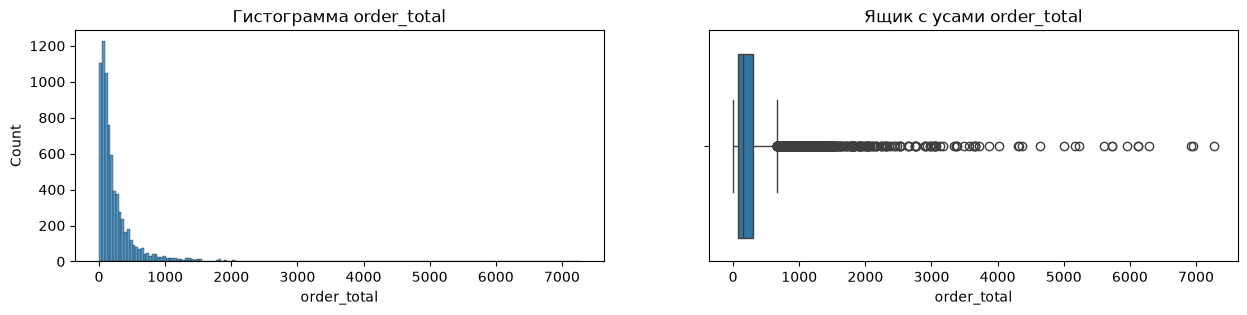

In [3]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    sns.histplot(data=data, x=variable, ax=ax[0])
    sns.boxplot(data=data, x=variable, ax=ax[1])
    ax[0].set_title(f"Гистограмма {variable}")
    ax[1].set_title(f"Ящик с усами {variable}")
    plt.show()

print(df["order_total"].describe())
visualize_distribution(df, variable="order_total")

# 2. Чистим данные

In [4]:
# пропусков нет, оставляем все строки
print(df.isna().sum().sum(), df.shape)

0 (7416, 8)


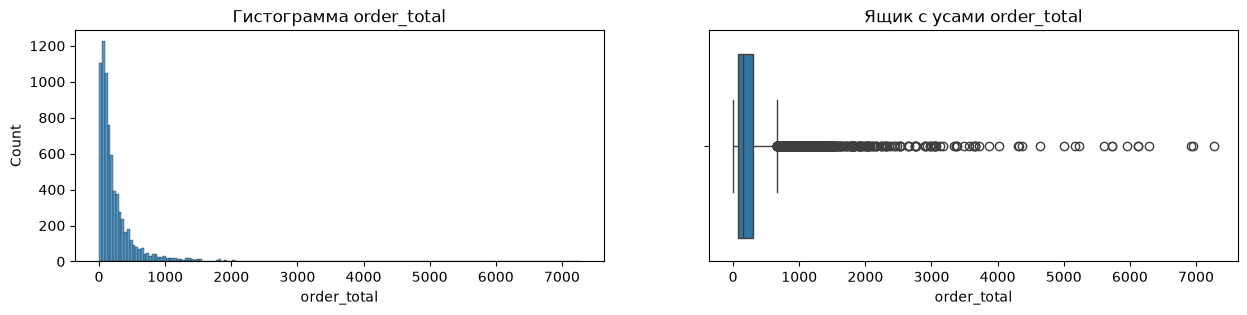

In [5]:
visualize_distribution(df, variable="order_total")

# 3. Обучим модели линейной регрессии

In [6]:
TARGET = "order_total"
SPLIT_SIZE, SPLIT_SEED = 0.2, 7

behavioral = ["days_since_registration", "session_count_30d", "distinct_event_types_30d", "favorites_count_before"]

def make_design(frame, columns, dummy_col=None):
    X = frame[columns].astype(float)
    if dummy_col:
        d = pd.get_dummies(frame[dummy_col], prefix=dummy_col, drop_first=True).astype(float)
        X = pd.concat([X, d], axis=1)
    return X

def split_train_test(X, y):
    return train_test_split(X, y, test_size=SPLIT_SIZE, random_state=SPLIT_SEED)

def visualize_prediction(y_true, y_pred, title):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.scatterplot(x=y_true.values.ravel(), y=y_pred.ravel(), ax=ax, alpha=0.5)
    lim = [y_true.min(), y_true.max()]
    ax.plot(lim, lim, linestyle="--", color="lightblue")
    ax.set_title(title)
    ax.set_xlabel("true y")
    ax.set_ylabel("pred y")
    plt.show()

def show_metrics(y_true, y_pred):
    print("Среднее Y: ", np.mean(y_true))
    print("Ст. отклонение Y: ", np.std(y_true))
    print("MSE: ", mean_squared_error(y_true, y_pred))
    print("RMSE: ", root_mean_squared_error(y_true, y_pred))
    print("MAE: ", mean_absolute_error(y_true, y_pred))
    print("MAPE: ", mean_absolute_percentage_error(y_true, y_pred))
    print("R2: ", r2_score(y_true, y_pred))

#### Модель 1: вовлечённость $order\_total_i = w_0 + w_1 \cdot days\_since\_registration_i + w_2 \cdot session\_count\_30d_i + w_3 \cdot distinct\_event\_types\_30d_i + w_4 \cdot favorites\_count\_before_i$

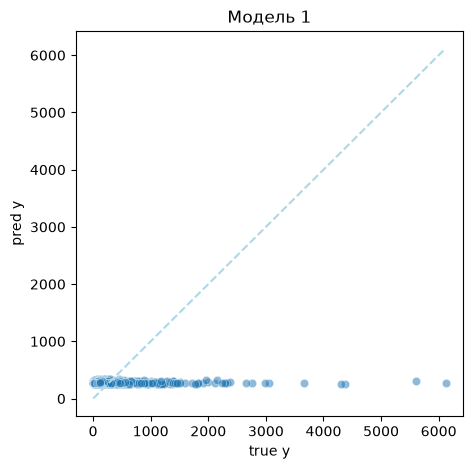

Среднее Y:  280.13446765498657
Ст. отклонение Y:  443.5905219327517
MSE:  197197.5302484083
RMSE:  444.06928541434644
MAE:  244.84730770824382
MAPE:  3.09419736261474
R2:  -0.002159747878231144


In [7]:
X = make_design(df, behavioral)
X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
visualize_prediction(y_test, y_pred, "Модель 1")
show_metrics(y_test, y_pred)

#### Модель 2: + quantity $order\_total_i = w_0 + w_1 \cdot days\_since\_registration_i + w_2 \cdot session\_count\_30d_i + w_3 \cdot distinct\_event\_types\_30d_i + w_4 \cdot favorites\_count\_before_i + w_5 \cdot quantity_i$

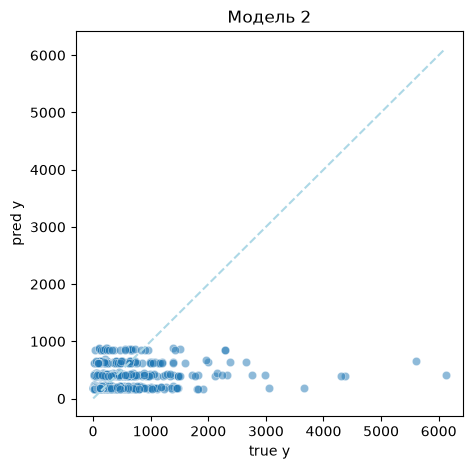

Среднее Y:  280.13446765498657
Ст. отклонение Y:  443.5905219327517
MSE:  180753.12306666278
RMSE:  425.15070629914607
MAE:  223.9752832376818
MAPE:  2.3866064888441816
R2:  0.08141088779101602


In [8]:
X = make_design(df, behavioral + ["quantity"])
X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
visualize_prediction(y_test, y_pred, "Модель 2")
show_metrics(y_test, y_pred)

#### Модель 3: + category\_name $order\_total_i = w_0 + w_1 \cdot days\_since\_registration_i + w_2 \cdot session\_count\_30d_i + w_3 \cdot distinct\_event\_types\_30d_i + w_4 \cdot favorites\_count\_before_i + w_5 \cdot quantity_i + \sum_k w_k \cdot \mathbb{1}[category\_name_i = k]$

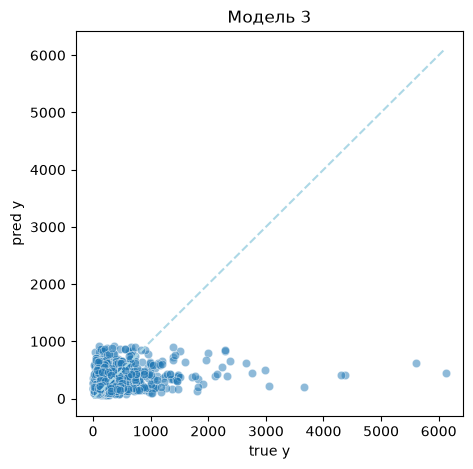

Среднее Y:  280.13446765498657
Ст. отклонение Y:  443.5905219327517
MSE:  180277.8383214299
RMSE:  424.5913780582808
MAE:  227.35713688121882
MAPE:  2.4016117131820014
R2:  0.08382628944362769


In [9]:
X = make_design(df, behavioral + ["quantity"], "category_name")
X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
visualize_prediction(y_test, y_pred, "Модель 3")
show_metrics(y_test, y_pred)

#### Модель 4: только структура $order\_total_i = w_0 + w_1 \cdot quantity_i + \sum_k w_k \cdot \mathbb{1}[category\_name_i = k]$

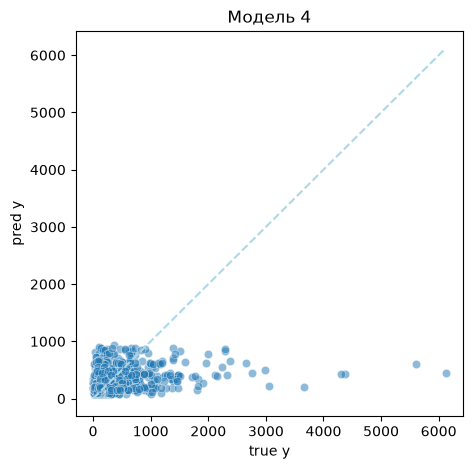

Среднее Y:  280.13446765498657
Ст. отклонение Y:  443.5905219327517
MSE:  179761.34401033036
RMSE:  423.9827166410564
MAE:  226.4759196745844
MAPE:  2.400036300506482
R2:  0.08645111850685194


In [10]:
X = make_design(df, ["quantity"], "category_name")
X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
visualize_prediction(y_test, y_pred, "Модель 4")
show_metrics(y_test, y_pred)

# 4. Интерпретируем полученную модель

In [11]:
# интерпретируем модель 4 — лучшую по R² (проверка выбора в разделе 5)
best_cols, best_dummy = ["quantity"], "category_name"
X = make_design(df, best_cols, best_dummy)
X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
best_model = LinearRegression().fit(X_train, y_train)
pd.Series(dict(zip(X_train.columns.tolist() + ["intercept"],
                   best_model.coef_.tolist() + [best_model.intercept_]))).round(5)

quantity                      223.95243
category_name_Automotive     -154.14408
category_name_Beauty          -97.62654
category_name_Beverages      -207.33959
category_name_Books          -118.64516
category_name_Clothing       -125.73808
category_name_Electronics     -98.85603
category_name_Food           -120.58556
category_name_Furniture      -188.13160
category_name_Gaming         -129.12291
category_name_Garden          -85.80968
category_name_Headphones     -125.79189
category_name_Health          -98.38351
category_name_Home             27.24463
category_name_Jewelry         -50.34690
category_name_Kitchen         -87.12061
category_name_Laptops        -124.66634
category_name_Music          -158.26379
category_name_Office          -36.50091
category_name_Other          -117.45432
category_name_Outdoor         -41.15723
category_name_Pet Supplies   -112.47217
category_name_Photography    -201.75937
category_name_Shoes          -152.43514
category_name_Smartphones    -221.42305


**Что означают коэффициенты (модель 4):**
- `quantity` ≈ +224: каждая единица товара добавляет к сумме заказа около 224;
- категории сравниваются с базовой `Accessories` (первая по алфавиту, в модели не отдельным столбцом): `Smartphones` −221, `Beverages` −207, `Photography` −202, `Furniture` −188;
- признаков вовлечённости в лучшей модели нет.

# 5. Повышаем качество модели

#### Сравнение моделей

In [12]:
SPECS = [
    ("Модель 1. Вовлечённость", behavioral, None),
    ("Модель 2. + quantity", behavioral + ["quantity"], None),
    ("Модель 3. + category_name", behavioral + ["quantity"], "category_name"),
    ("Модель 4. Только структура", ["quantity"], "category_name"),
]
rows = {}
for name, cols, dummy in SPECS:
    X = make_design(df, cols, dummy)
    X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
    pred = LinearRegression().fit(X_train, y_train).predict(X_test)
    rows[name] = {"R2": r2_score(y_test, pred),
                  "RMSE": root_mean_squared_error(y_test, pred),
                  "MAE": mean_absolute_error(y_test, pred),
                  "признаков": X_train.shape[1]}
metrics_df = pd.DataFrame(rows).T
best_name = metrics_df["R2"].astype(float).idxmax()
print("Лучшая модель:", best_name)
metrics_df

Лучшая модель: Модель 4. Только структура


,R2,RMSE,MAE,признаков
Модель 1. Вовлечённость,-0.002160,444.069285,244.847308,4.0
Модель 2. + quantity,0.081411,425.150706,223.975283,5.0
Модель 3. + category_name,0.083826,424.591378,227.357137,34.0
Модель 4. Только структура,0.086451,423.982717,226.475920,30.0


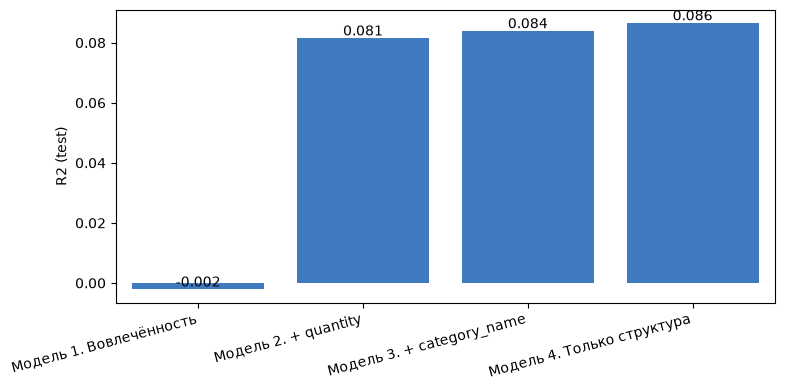

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=metrics_df.index, y=metrics_df["R2"].astype(float), ax=ax, color="#2a78d6")
ax.set_ylabel("R2 (test)")
ax.set_xlabel("")
for i, v in enumerate(metrics_df["R2"].astype(float)):
    ax.text(i, v + 0.001, f"{v:.3f}", ha="center")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**Вывод:** лучшая модель 4 (структура покупки, R² 0.086).
- вовлечённость сама по себе: R² ≈ 0;
- + `quantity`: R² 0.081, главный прирост;
- + категория: R² 0.084;
- только структура: R² 0.086, не хуже полной модели. Вовлечённость лишняя.

#### Мультиколлинеарность

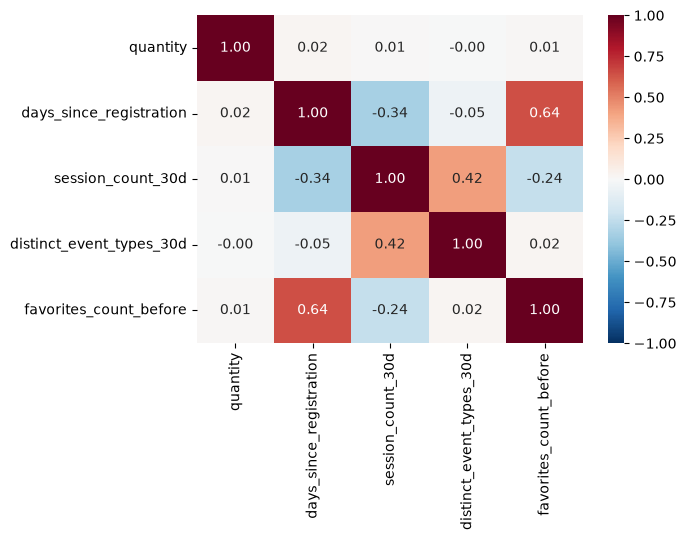

In [14]:
corr_cols = ["quantity", "days_since_registration", "session_count_30d", "distinct_event_types_30d", "favorites_count_before"]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
plt.tight_layout()
plt.show()

**Вывод:** `quantity` почти не связан с признаками вовлечённости (|r| ≤ 0.01). Между собой признаки вовлечённости связаны умеренно: дни с регистрации и избранное (0.64), дни и сессии (−0.34). Мультиколлинеарности, которая портила бы коэффициенты, здесь нет. Связь дней и избранного на вывод не влияет: вовлечённость в лучшей модели не используется.

# 6. Примеры форм зависимостей между Х и Y

#### Точечные диаграммы: таргет и признаки

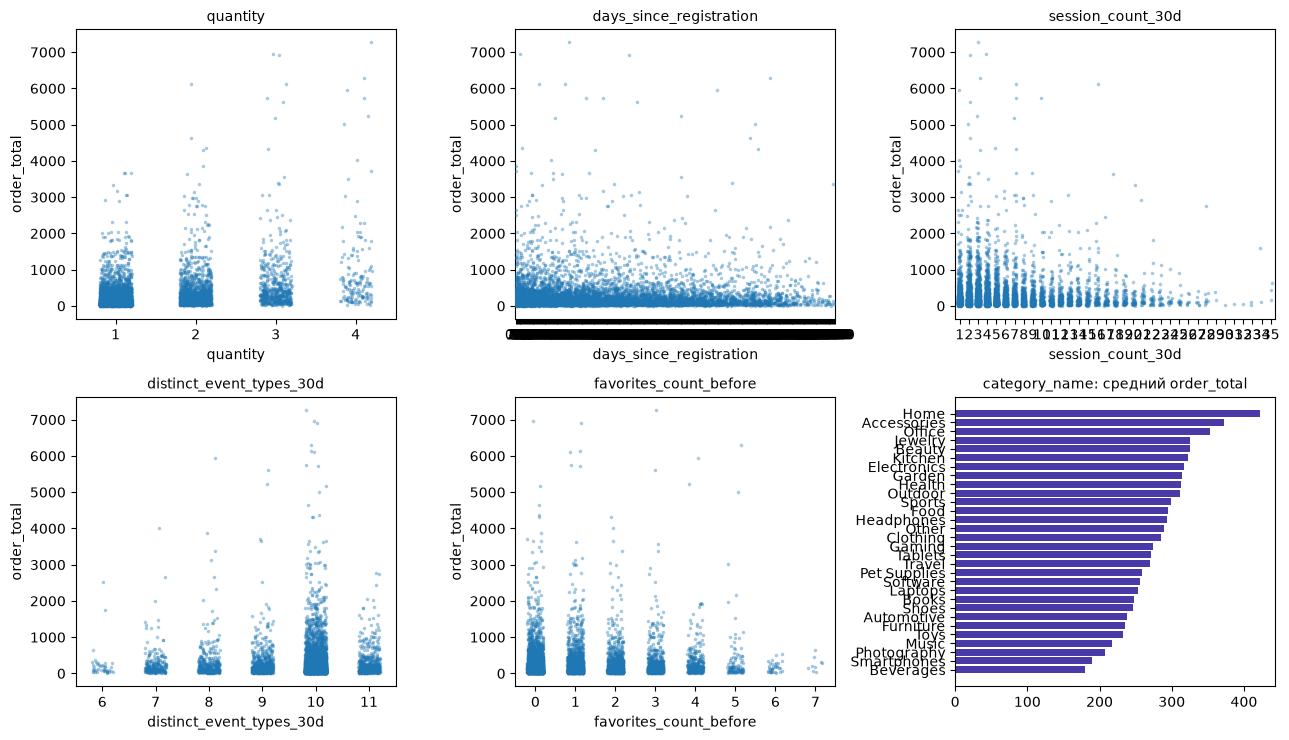

In [15]:
num_cols = ["quantity", "days_since_registration", "session_count_30d",
            "distinct_event_types_30d", "favorites_count_before"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.stripplot(x=df[col], y=df[TARGET], ax=ax, size=2.5, alpha=0.4, jitter=0.2)
    ax.set_title(col, fontsize=10)

# средний чек по категории
cat_means = df.groupby("category_name")[TARGET].mean().sort_values()
axes[5].barh(cat_means.index, cat_means.values, color="#4a3aa7")
axes[5].set_title("category_name: средний order_total", fontsize=10)
plt.tight_layout()
plt.show()

**Что видно:**
- `quantity`: при большем количестве верхняя граница облака выше, то есть крупные заказы чаще при 3–4 единицах;
- признаки вовлечённости (дни, сессии, типы событий, избранное): облака плотные, без наклона;
- категория: средний чек от ≈180 (`Beverages`) до ≈420 (`Home`), разница почти вдвое;
- таргет скошен: медиана 146, среднее 279.

#### Линейная зависимость

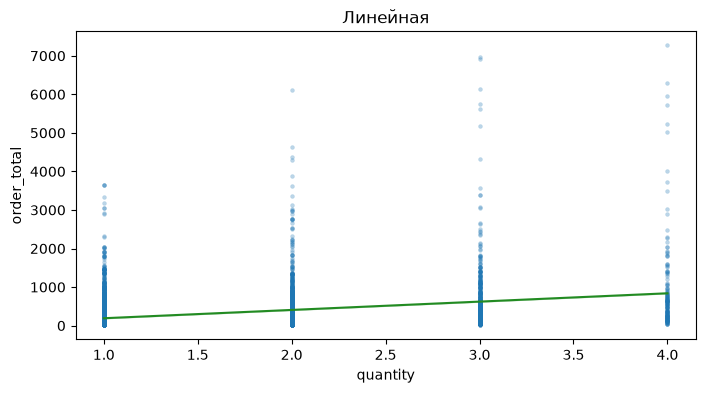

R2: 0.1147   RMSE: 431.5168


In [16]:
def plot_form(x, X_form, y, name, xlabel, color):
    reg = LinearRegression().fit(X_form, y)
    pred = reg.predict(X_form)
    order = np.argsort(x)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.scatterplot(x=x, y=y, ax=ax, s=8, alpha=0.3, edgecolor=None)
    sns.lineplot(x=x[order], y=pred[order], ax=ax, color=color)
    ax.set_title(name)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("order_total")
    plt.show()
    print(f"R2: {r2_score(y, pred):.4f}   RMSE: {root_mean_squared_error(y, pred):.4f}")

x_qty = df["quantity"].values.astype(float)
y_total = df[TARGET].values
plot_form(x_qty, x_qty.reshape(-1, 1), y_total, "Линейная", "quantity", "forestgreen")

#### Логарифмическая зависимость

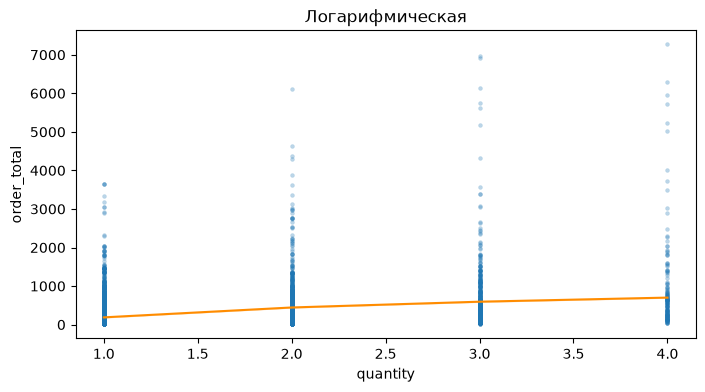

R2: 0.1065   RMSE: 433.4953


In [17]:
plot_form(x_qty, np.log(x_qty).reshape(-1, 1), y_total, "Логарифмическая", "quantity", "darkorange")

#### Гипербола

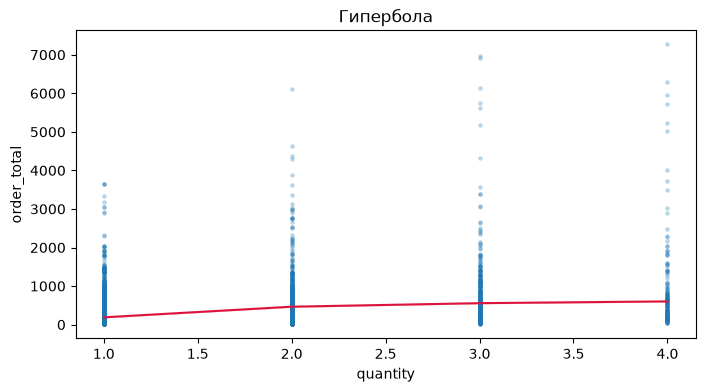

R2: 0.0971   RMSE: 435.7786


In [18]:
plot_form(x_qty, (1 / x_qty).reshape(-1, 1), y_total, "Гипербола", "quantity", "crimson")

#### Полином второй степени

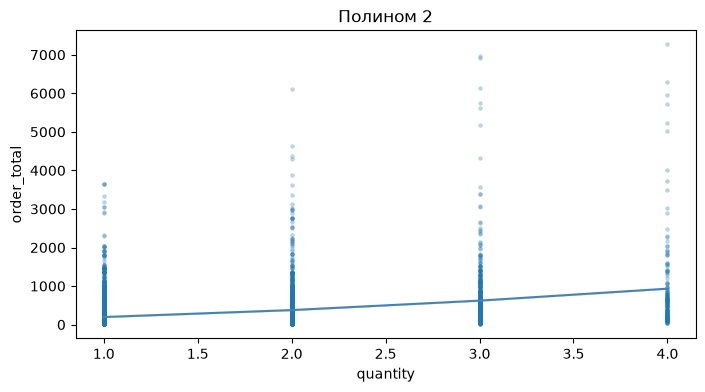

R2: 0.1165   RMSE: 431.0689


In [19]:
plot_form(x_qty, np.vstack([x_qty, x_qty ** 2]).T, y_total, "Полином 2", "quantity", "steelblue")

**Вывод:** зависимость от `quantity` почти линейная: полином 2 (R² 0.117) ≈ линейная (0.115) > логарифмическая (0.107) > гипербола (0.097). Разница мала, поэтому выбираем простую линейную форму.

# 7. Множественная регрессия

#### Корреляции признаков

In [20]:
df[["quantity"] + behavioral].corr().round(2)

,quantity,days_since_registration,session_count_30d,distinct_event_types_30d,favorites_count_before
quantity,1.00,0.02,0.01,-0.00,0.01
days_since_registration,0.02,1.00,-0.34,-0.05,0.64
session_count_30d,0.01,-0.34,1.00,0.42,-0.24
distinct_event_types_30d,-0.00,-0.05,0.42,1.00,0.02
favorites_count_before,0.01,0.64,-0.24,0.02,1.00


#### Модель 3: все признаки (множественная регрессия)

In [21]:
X = make_design(df, behavioral + ["quantity"], "category_name")
X_train, X_test, y_train, y_test = split_train_test(X, df[TARGET])
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
show_metrics(y_test, y_pred)
pd.Series(dict(zip(X_train.columns.tolist() + ["intercept"],
                   model.coef_.tolist() + [model.intercept_]))).round(5)

Среднее Y:  280.13446765498657
Ст. отклонение Y:  443.5905219327517
MSE:  180277.8383214299
RMSE:  424.5913780582808
MAE:  227.35713688121882
MAPE:  2.4016117131820014
R2:  0.08382628944362769


days_since_registration         0.00396
session_count_30d               0.45943
distinct_event_types_30d       -4.71925
favorites_count_before         11.07648
quantity                      223.70327
category_name_Automotive     -155.01173
category_name_Beauty          -98.57982
category_name_Beverages      -209.11436
category_name_Books          -118.53180
category_name_Clothing       -126.74750
category_name_Electronics     -99.72539
category_name_Food           -122.68257
category_name_Furniture      -189.50457
category_name_Gaming         -129.23330
category_name_Garden          -86.96011
category_name_Headphones     -125.65434
category_name_Health          -98.00771
category_name_Home             29.19491
category_name_Jewelry         -50.85666
category_name_Kitchen         -86.43248
category_name_Laptops        -124.28741
category_name_Music          -158.48695
category_name_Office          -38.07390
category_name_Other          -117.61307
category_name_Outdoor         -41.70680


**Вывод:** модель со всеми признаками даёт R² 0.084, это не выше модели 4 (0.086). Вклад вовлечённости мал: сессии +0.5, избранное +11 к сумме заказа. Главный фактор — `quantity` (+224).

# 8. Проверим устойчивость модели на разных выборках

In [22]:
best_X = make_design(df, best_cols, best_dummy)
metrics_list, coefs_list = [], []
for random_state in range(0, 20, 2):
    X_train, X_test, y_train, y_test = train_test_split(best_X, df[TARGET], test_size=SPLIT_SIZE, random_state=random_state)
    reg = LinearRegression().fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    metrics_list.append({"random_state": random_state,
                         "RMSE": root_mean_squared_error(y_test, y_pred),
                         "MAE": mean_absolute_error(y_test, y_pred),
                         "R2": r2_score(y_test, y_pred)})
    coefs_list.append(pd.Series(reg.coef_, index=best_X.columns, name=random_state))

stab = pd.DataFrame(metrics_list).set_index("random_state")
print(stab.describe().loc[["mean", "std"]].round(4))
stab

         RMSE       MAE      R2
mean  434.197  223.6712  0.1213
std    37.510    7.9519  0.0231


,RMSE,MAE,R2
random_state,,,
0,408.148072,220.447613,0.135604
2,436.494359,226.327263,0.081577
4,486.407087,230.490034,0.142184
6,472.871146,235.263737,0.108244
8,356.987733,207.626609,0.137795
10,464.625094,228.658859,0.127516
12,405.795855,216.684832,0.119488
14,431.755881,220.214395,0.153950
16,438.247730,228.740945,0.089561


In [23]:
pd.concat(coefs_list, axis=1).round(4)

,0,2,4,6,8,10,12,14,16,18
quantity,219.4595,223.5892,203.2778,214.1284,220.7619,210.3920,219.5597,205.8877,222.1934,216.1700
category_name_Automotive,-126.5047,-166.4322,-101.1329,-87.6378,-158.4759,-138.8869,-88.2683,-128.2460,-165.0264,-128.2923
category_name_Beauty,-50.3077,-99.8525,-51.2297,-29.0703,-80.1589,-90.2687,-45.1404,-55.8892,-126.4516,-36.0199
category_name_Beverages,-181.7694,-218.4907,-173.4362,-133.2796,-217.3947,-192.7931,-154.8569,-189.5759,-222.4440,-182.3910
category_name_Books,-98.7296,-122.2729,-94.8093,-44.7786,-145.1937,-104.7980,-65.5761,-103.1788,-148.0353,-96.9952
category_name_Clothing,-101.8751,-116.6657,-69.4670,-38.6516,-120.0127,-95.6217,-53.1028,-72.9978,-133.6902,-71.9365
category_name_Electronics,-64.1228,-75.1316,-56.2820,-21.4878,-86.4250,-93.0741,-23.8822,-65.9731,-123.0341,-53.8494
category_name_Food,-78.5179,-104.9251,-93.1543,-73.7252,-123.3592,-75.6377,-57.7244,-104.3677,-136.2270,-77.6305
category_name_Furniture,-150.5466,-178.6284,-153.2444,-111.0602,-183.2464,-161.2785,-125.2880,-168.1976,-198.1132,-152.5769
category_name_Gaming,-93.1279,-99.0946,-84.8957,-37.1759,-124.3442,-106.6341,-59.5288,-96.3892,-137.6600,-100.8643


**Вывод:** R² на 10 разбиениях от 0.08 до 0.15 (среднее 0.121, σ 0.023). Качество низкое и нестабильное: модель слабая, а не просто шумная.

# 9. Variance inflation factor

In [24]:
vif_X = make_design(df, ["quantity"] + behavioral)
vif = pd.DataFrame({"feature": vif_X.columns,
                    "VIF": [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])]})
vif.sort_values("VIF", ascending=False).reset_index(drop=True)

,feature,VIF
0,days_since_registration,1.810680
1,favorites_count_before,1.720264
2,session_count_30d,1.388522
3,distinct_event_types_30d,1.239436
4,quantity,1.000512


**Вывод:** VIF для признаков вовлечённости и `quantity` от 1.0 до 1.8, мультиколлинеарности нет.

# 10. Lasso регрессия

Признаки масштабируем: иначе сила штрафа зависит от единиц (сумма кредита в млн, срок в месяцах).

In [25]:
reg_X = make_design(df, behavioral + ["quantity"], "category_name")
X_train, X_test, y_train, y_test = train_test_split(reg_X, df[TARGET], test_size=0.2, random_state=7)

lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=0.1)).fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)
pd.DataFrame(data={"MSE": mean_squared_error(y_test, y_pred),
                   "RMSE": root_mean_squared_error(y_test, y_pred),
                   "MAE": mean_absolute_error(y_test, y_pred),
                   "MAPE": mean_absolute_percentage_error(y_test, y_pred),
                   "R2": r2_score(y_test, y_pred)}, index=[0])

,MSE,RMSE,MAE,MAPE,R2
0,180160.140402,424.452754,227.172107,2.401181,0.084424


In [26]:
pd.DataFrame(index=reg_X.columns, data=lasso_model[-1].coef_).T

,days_since_registration,session_count_30d,distinct_event_types_30d,favorites_count_before,quantity,category_name_Automotive,category_name_Beauty,category_name_Beverages,category_name_Books,category_name_Clothing,...,category_name_Outdoor,category_name_Pet Supplies,category_name_Photography,category_name_Shoes,category_name_Smartphones,category_name_Software,category_name_Sports,category_name_Tablets,category_name_Toys,category_name_Travel
0,0.251951,1.952989,-3.71394,14.379109,161.653689,-25.818622,-14.636617,-37.534334,-16.246598,-17.522025,...,-4.758919,-17.051109,-34.155831,-26.964028,-39.894932,-23.444884,-20.395737,-26.504214,-29.187858,-20.721863


# 11. Ridge регрессия

In [27]:
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=0.1)).fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
pd.DataFrame(data={"MSE": mean_squared_error(y_test, y_pred),
                   "RMSE": root_mean_squared_error(y_test, y_pred),
                   "MAE": mean_absolute_error(y_test, y_pred),
                   "MAPE": mean_absolute_percentage_error(y_test, y_pred),
                   "R2": r2_score(y_test, y_pred)}, index=[0])

,MSE,RMSE,MAE,MAPE,R2
0,180277.185307,424.590609,227.356172,2.401618,0.08383


In [28]:
pd.DataFrame(index=reg_X.columns, data=ridge_model[-1].coef_).T

,days_since_registration,session_count_30d,distinct_event_types_30d,favorites_count_before,quantity,category_name_Automotive,category_name_Beauty,category_name_Beverages,category_name_Books,category_name_Clothing,...,category_name_Outdoor,category_name_Pet Supplies,category_name_Photography,category_name_Shoes,category_name_Smartphones,category_name_Software,category_name_Sports,category_name_Tablets,category_name_Toys,category_name_Travel
0,0.324014,2.218019,-3.977112,14.517123,161.754589,-28.436293,-17.125288,-40.274428,-18.478572,-19.759914,...,-7.239837,-19.511715,-36.742711,-29.729162,-42.606476,-25.91506,-22.942903,-29.13133,-31.956844,-23.104627


# 12. Elastic Net регрессия

In [29]:
elnet_model = make_pipeline(StandardScaler(), ElasticNet(alpha=0.1)).fit(X_train, y_train)
y_pred = elnet_model.predict(X_test)
pd.DataFrame(data={"MSE": mean_squared_error(y_test, y_pred),
                   "RMSE": root_mean_squared_error(y_test, y_pred),
                   "MAE": mean_absolute_error(y_test, y_pred),
                   "MAPE": mean_absolute_percentage_error(y_test, y_pred),
                   "R2": r2_score(y_test, y_pred)}, index=[0])

,MSE,RMSE,MAE,MAPE,R2
0,179437.397319,423.600516,225.974519,2.426325,0.088097


In [30]:
pd.DataFrame(index=reg_X.columns, data=elnet_model[-1].coef_).T

,days_since_registration,session_count_30d,distinct_event_types_30d,favorites_count_before,quantity,category_name_Automotive,category_name_Beauty,category_name_Beverages,category_name_Books,category_name_Clothing,...,category_name_Outdoor,category_name_Pet Supplies,category_name_Photography,category_name_Shoes,category_name_Smartphones,category_name_Software,category_name_Sports,category_name_Tablets,category_name_Toys,category_name_Travel
0,1.142749,1.833423,-3.193035,13.120452,153.889738,-14.432582,-4.05212,-25.140897,-6.962948,-8.064141,...,4.806077,-6.841215,-22.453483,-14.879975,-27.398039,-12.655201,-9.356593,-14.920779,-16.887505,-10.447566


## Выводы

- Сумму заказа определяет структура покупки: количество единиц и категория.
- Активность до заказа (дни, сессии, типы событий, избранное) не добавляет качества.
- R² ≈ 0.09: без цены товара предсказать сумму заказа трудно. Цена в модели не используется намеренно.
- Таргет сильно скошен (skew ≈ 6), поэтому логарифм таргета мог бы улучшить модель. Этого в задании нет, поэтому не делал.
- Регуляризация и разбиение на выборки результат не меняют.